In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
import pickle

# ------------------------------
# 1. Data Preparation
# ------------------------------
def load_CSN_data():
    csv_path = '../../CSN_Viability_Database_2025.csv'
    return pd.read_csv(csv_path)

CSN = load_CSN_data()
CSN = CSN.drop(['Example ID', 'Source', 'Figure ID', 'Data Provider', 'PI',
                'Date Received', 'Data Measurment Published', 'Prior Exposure', 'Comments', 'Error'], axis=1)

CSN_prepared = pd.get_dummies(CSN, dtype=int)
CSN_prepared['Surface Area per Liter'] = CSN_prepared['Surface Area (NMC) (m2/g)'] * CSN_prepared['Concentration (mg/L)']
CSN_prepared = CSN_prepared.drop(['Surface Area (NMC) (m2/g)'], axis=1)
CSN_prepared['log Concentration'] = np.log10(CSN_prepared['Concentration (mg/L)'] + 1e-9)
CSN_prepared = CSN_prepared.drop(['Concentration (mg/L)'], axis=1)

# T38
CSN_new = CSN_prepared[-38:]
CSN_prepared = CSN_prepared.drop(CSN_prepared.index[-38:])
X_train = CSN_prepared.drop(['Viability_Fraction'], axis=1)
y_train = CSN_prepared['Viability_Fraction']

X_new = CSN_new.drop(['Viability_Fraction'], axis=1)
y_new = CSN_new['Viability_Fraction']


# ------------------------------
# 2. Define Dataset and DataLoader
# ------------------------------
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create dataset and dataloader for prediction
predict_dataset = TabularDataset(X_new, y_new)
predict_loader = DataLoader(predict_dataset, batch_size=1, shuffle=False)

# ------------------------------
# 3. Define the CNN Model
# ------------------------------
class CNN(nn.Module):
    def __init__(self, num_features, feature_dim=128):
        super(CNN, self).__init__()
        # Input shape: (batch_size, 1, num_features)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # Output: (16, num_features)
        self.pool1 = nn.MaxPool1d(kernel_size=2)  # Output: (16, num_features//2)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)  # Output: (32, num_features//2)
        self.pool2 = nn.MaxPool1d(kernel_size=2)  # Output: (32, num_features//4)
        self.flatten = nn.Flatten()
        conv_out_size = num_features // 4
        self.fc1 = nn.Linear(32 * conv_out_size, feature_dim)  # get 128 features
        self.fc2 = nn.Linear(feature_dim, 1)  # regression output

    def forward(self, x, feature_extract=False):
        x = x.unsqueeze(1)  # add channel dimension
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.flatten(x)
        features = F.relu(self.fc1(x))
        if feature_extract:
            return features
        out = self.fc2(features)
        return out

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_features = X_new.shape[1]
# Initialize CNN model
model = CNN(num_features=num_features, feature_dim=128).to(device)

# ------------------------------
# 4. Load the Saved CNN and XGBoost Models
# ------------------------------
# Load CNN model weights
cnn_weights_path = 'cnn_model_weights.pth'
model.load_state_dict(torch.load(cnn_weights_path, map_location=device))
model.eval()
print("CNN model weights loaded from", cnn_weights_path)

# Load XGBoost model using pickle
xgb_model_path = 'MCCX-0_283T38.pkl'
with open(xgb_model_path, 'rb') as f:
    reg = pickle.load(f)
print("XGBoost model loaded from", xgb_model_path)

# ------------------------------
# 5. Extract Features using CNN (for XGBoost)
# ------------------------------
def extract_features(loader, model):
    features_list = []
    targets_list = []
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            feats = model(data, feature_extract=True)  # extract features
            features_list.append(feats.cpu().numpy())
            targets_list.append(target.cpu().numpy())
    features = np.concatenate(features_list, axis=0)
    targets = np.concatenate(targets_list, axis=0).flatten()
    return features, targets

predict_features, true_targets = extract_features(predict_loader, model)

# ------------------------------
# 6. Predict using XGBoost Model
# ------------------------------
y_pred = reg.predict(predict_features)
print("Predictions on new data:")
print(y_pred)


CNN model weights loaded from cnn_model_weights.pth
XGBoost model loaded from MCCX-0_283T38.pkl
Predictions on new data:
[0.9937168  0.51057523 0.23067135 0.24168193 0.24168193 0.9923317
 0.49076378 0.49261513 0.52151006 0.50935215 0.5085244  1.051603
 0.90128803 0.5202707  0.5187921  0.52159137 1.1206156  1.2606318
 1.2667471  1.2677802  1.2673821  1.2673821  1.017048   0.9194495
 0.9258101  0.9258101  0.9258101  0.9194495  0.9194495  0.9194495
 1.0637946  0.28578824 0.772445   0.772445   0.7684082  0.7684082
 0.7684082  0.7684082 ]


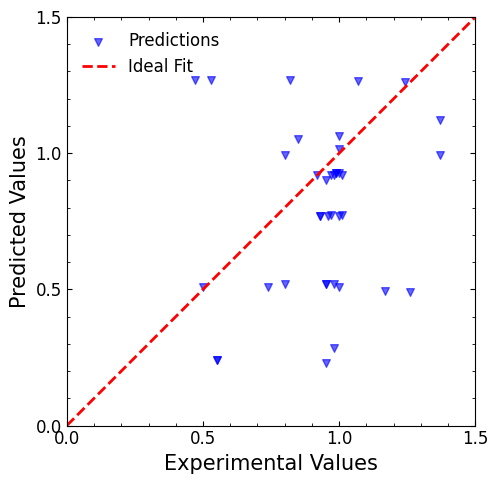

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import numpy as np

# ------------------------------
# 1. Font Sizing & Style Configuration
# ------------------------------
SMALL_SIZE = 12
MEDIUM_SIZE = 15
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# ------------------------------
# 2. Plotting Initialization
# ------------------------------
fig = plt.figure(figsize=(6.5, 5))
plt.rcParams["mathtext.fontset"] = "cm"
plt.minorticks_on()
plt.tick_params(axis='both', bottom=True, top=True, left=True, right=True, 
                direction='in', which='both')

# Plot the scatter points (Assuming true_targets and y_pred are predefined)
plt.scatter(true_targets, y_pred,
            color='blue', marker='v', s=30, alpha=0.6, 
            label="Predictions")

# Ideal Fit Line
min_val, max_val = 0, 1.5
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, 
         linestyle='--', label="Ideal Fit")

# ------------------------------
# 3. MAE Annotation
# ------------------------------
'''
test_mae = mean_absolute_error(true_targets, y_pred)
# Add MAE information to the bottom right using axes coordinates
mae_text = f"Test MAE = {test_mae:.4f}"
plt.gca().text(0.95, 0.05, mae_text, transform=plt.gca().transAxes,
               fontsize=SMALL_SIZE, verticalalignment='bottom', 
               horizontalalignment='right')
'''
# ------------------------------
# 4. Axis & Tick Formatting
# ------------------------------
plt.xlabel("Experimental Values")
plt.ylabel("Predicted Values")

plt.xlim(0, 1.5)
plt.xticks(np.arange(0, 1.6, 0.5))
plt.ylim(0, 1.5)
plt.yticks(np.arange(0, 1.6, 0.5))

plt.legend(framealpha=0.0, loc='upper left', ncol=1)

fig.tight_layout()
plt.gca().set_aspect('equal')

# ------------------------------
# 5. Export
# ------------------------------
plt.savefig('MCCX-0_283T38.pdf', dpi=300, bbox_inches='tight')
plt.savefig('MCCX-0_283T38.svg', dpi=300, bbox_inches='tight')
plt.show()